In [14]:
import numpy as np
import pandas as pd
import seaborn as sns

In [15]:
# knn regressor from scratch

class knn_regressor:

    # define constructor

    def __init__(self, k = 3):
        self.k = k

    # build a function for euclidian distance
    
    def e_distance(self, x1, x2):
        x1, x2 = np.array(x1), np.array(x2)
        return np.sqrt(np.sum((x2-x1) ** 2)) # took a slight peek to the notes here
    
    # build the fit function

    def fit(self, X_train, y_train):
        self.X_train = X_train
        self.y_train = y_train

    # build the predict function

    def predict(self, X_test):
        
        y_pred = []

        for x in X_test:
           
            # calculate distance of our new point from each of the points in x_train
            distances = []
            for x_train in self.X_train:
                distance = self.e_distance(x, x_train) # took a little help here as I was using variable i and x_train[i] or something
                distances.append(distance)
    
            # find the knn indices
            knn_indices = np.argsort(distances)[:self.k] # took a little peek here, actually took full help here
    
            # find the knn values of these indices by taking the values of that indice in y_train
            knn_values = []
            for i in knn_indices:
                values = self.y_train[i]
                knn_values.append(values)
            
            # find the mean of the values
            knn_mean = np.mean(knn_values)

            # append to our y_pred list
            y_pred.append(knn_mean)

        return np.array(y_pred)  

In [16]:
# data

X_train = [[1], [2], [3], [4], [5]]
y_train = [2, 4, 6, 8, 10]

X_test = [[1.5], [3.5], [6]]

In [17]:
# create model and predict

knn_regressor = knn_regressor()
knn_regressor.fit(X_train, y_train)
y_pred = knn_regressor.predict(X_test)

y_pred

array([4., 6., 8.])

<Axes: xlabel='x1', ylabel='labels'>

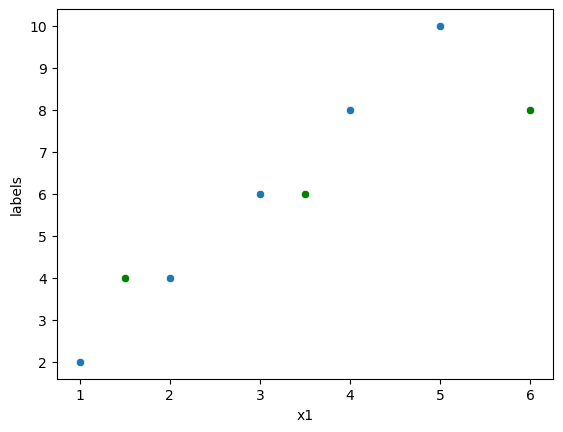

In [18]:
df_train = pd.DataFrame(X_train, columns = ["x1"])
df_train["labels"] = y_train

df_test = pd.DataFrame(X_test, columns = ["x1"])
df_test["labels"] = y_pred
sns.scatterplot(
    x = df_train["x1"],
    y = df_train["labels"]
)

sns.scatterplot(
    x = df_test["x1"],
    y = df_test["labels"],
    color = "green"
)

In [24]:
x1 = np.array([1,2])
x2 = np.array([3,4])
np.sqrt(np.sum((x2-x1) ** 2))

np.float64(2.8284271247461903)

In [30]:
x1 = np.argsort([3,1,5,4,2])
x1 = np.mean(x1)
x1

np.float64(2.0)